# Analyse Exploratoire des Données (EDA)

## Détection de Tweets Suspects



Ce notebook explore le jeu de données, visualise les distributions et documente les choix de prétraitement.

In [1]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from wordcloud import WordCloud

import sys

sys.path.append('..')

from src.preprocessing import clean_text



plt.style.use('ggplot')

%matplotlib inline

---

## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/raw/tweets.csv')

df.head()

,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1


---

## 2. Variables disponibles

In [3]:
print(f"Shape: {df.shape}")

print(f"Colonnes: {list(df.columns)}")

print(f"Types:\n{df.dtypes}")

df.info()

Shape: (60000, 2)
Colonnes: ['message', 'label']
Types:
message      str
label      int64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   message  60000 non-null  str  
 1   label    60000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 5.1 MB


**Variables :**

- `message` : texte du tweet (string)

- `label` : 0 = suspect, 1 = non suspect (int)

---

## 3. Valeurs manquantes

In [4]:
print("Valeurs manquantes:")

print(df.isnull().sum())



missing_message = df['message'].isnull().sum()

if missing_message > 0:

    print(f"\n{missing_message} tweets avec message manquant (seront ignorés)")

Valeurs manquantes:
message    0
label      0
dtype: int64


---

## 4. Distribution des classes

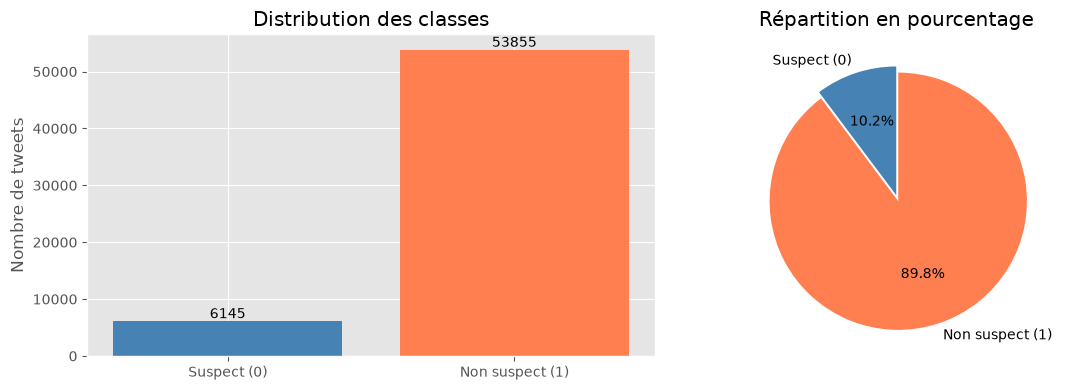

Ratio déséquilibré : 0.11:1
-> Une stratégie de gestion du déséquilibre sera nécessaire (class_weights, SMOTE...)


In [5]:
class_counts = df['label'].value_counts().sort_index()



fig, axes = plt.subplots(1, 2, figsize=(12, 4))



axes[0].bar(['Suspect (0)', 'Non suspect (1)'], class_counts.values,

           color=['steelblue', 'coral'])

axes[0].set_title('Distribution des classes')

axes[0].set_ylabel('Nombre de tweets')

for i, v in enumerate(class_counts.values):

    axes[0].text(i, v + 500, str(v), ha='center')



axes[1].pie(class_counts.values, labels=['Suspect (0)', 'Non suspect (1)'],

           autopct='%1.1f%%', colors=['steelblue', 'coral'],

           startangle=90, explode=(0, 0.05))

axes[1].set_title('Répartition en pourcentage')



plt.tight_layout()

plt.savefig('../reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')

plt.show()



print(f"Ratio déséquilibré : {class_counts[0]/class_counts[1]:.2f}:1")

print("-> Une stratégie de gestion du déséquilibre sera nécessaire (class_weights, SMOTE...)")

---

## 5. Longueur des tweets

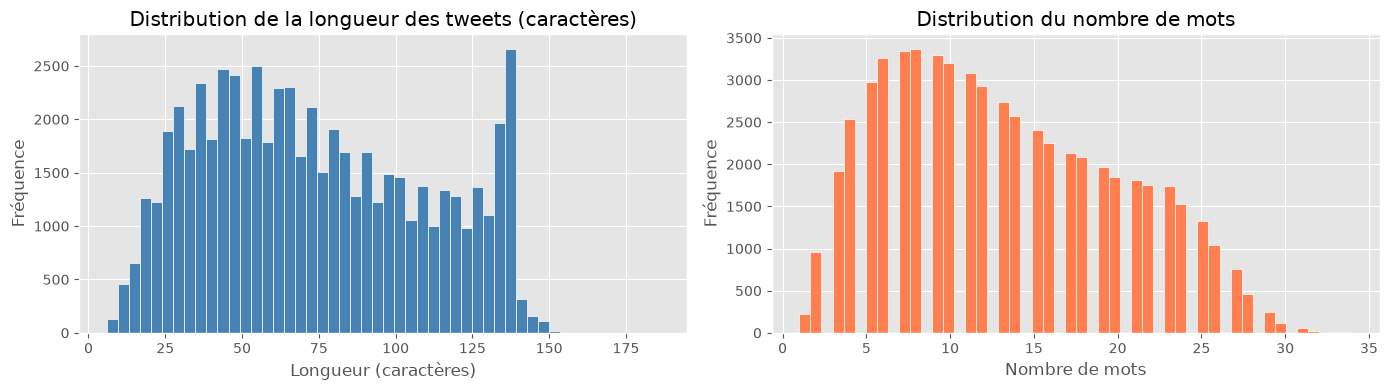

Statistiques longueur (caractères):
count    60000.000000
mean        73.749233
std         36.145122
min          6.000000
25%         44.000000
50%         69.000000
75%        103.000000
max        186.000000


In [6]:
df['text_length'] = df['message'].fillna('').apply(len)

df['word_count'] = df['message'].fillna('').apply(lambda x: len(x.split()))



fig, axes = plt.subplots(1, 2, figsize=(14, 4))



axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white')

axes[0].set_title('Distribution de la longueur des tweets (caractères)')

axes[0].set_xlabel('Longueur (caractères)')

axes[0].set_ylabel('Fréquence')



axes[1].hist(df['word_count'], bins=50, color='coral', edgecolor='white')

axes[1].set_title('Distribution du nombre de mots')

axes[1].set_xlabel('Nombre de mots')

axes[1].set_ylabel('Fréquence')



plt.tight_layout()

plt.savefig('../reports/figures/text_length_distribution.png', dpi=150, bbox_inches='tight')

plt.show()



print(f"Statistiques longueur (caractères):")

print(df['text_length'].describe().to_string())

---

## 6. Analyse par classe

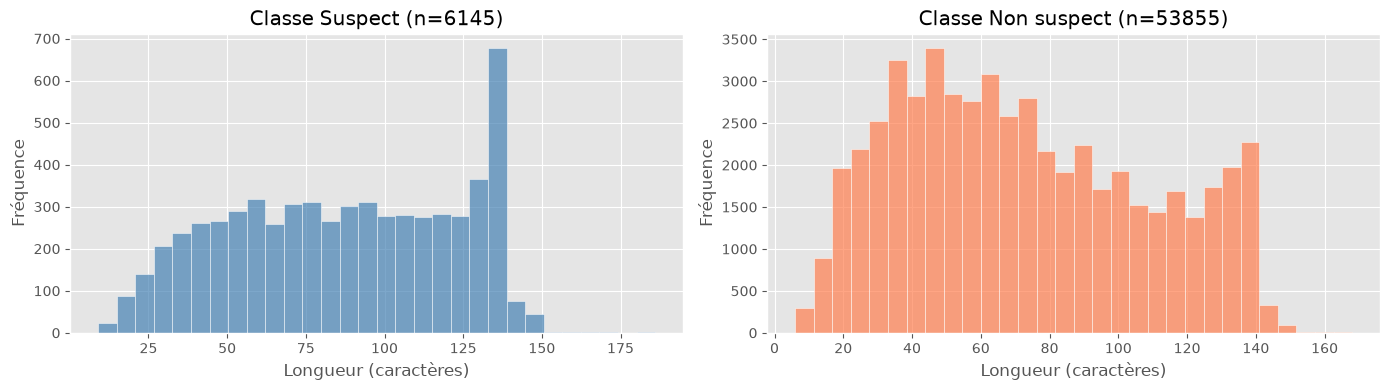

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))



for idx, label in enumerate([0, 1]):

    subset = df[df['label'] == label]['text_length']

    axes[idx].hist(subset, bins=30, color=['steelblue', 'coral'][idx], edgecolor='white', alpha=0.7)

    axes[idx].set_title(f"Classe {'Suspect' if label==0 else 'Non suspect'} (n={len(subset)})")

    axes[idx].set_xlabel('Longueur (caractères)')

    axes[idx].set_ylabel('Fréquence')



plt.tight_layout()

plt.savefig('../reports/figures/length_by_class.png', dpi=150, bbox_inches='tight')

plt.show()

---

## 7. WordCloud — Mots les plus fréquents

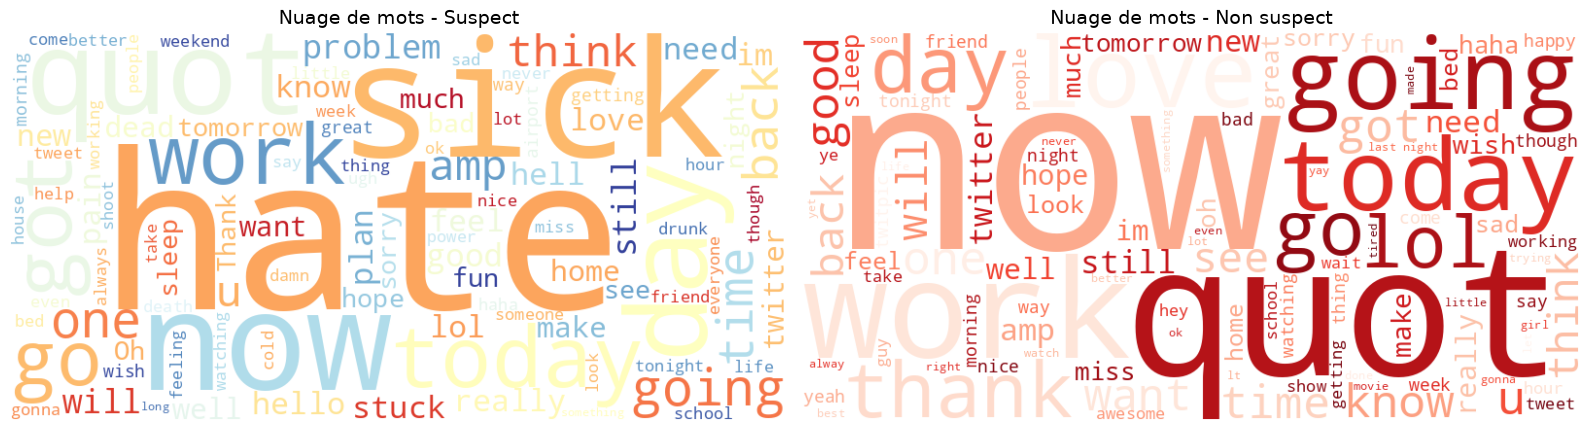

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))



for idx, label in enumerate([0, 1]):

    text = ' '.join(df[df['label'] == label]['message'].fillna('').astype(str))

    wordcloud = WordCloud(width=800, height=400,

                         background_color='white',

                         colormap='RdYlBu_r' if label == 0 else 'Reds',

                         max_words=100).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')

    axes[idx].axis('off')

    axes[idx].set_title(f"Nuage de mots - {'Suspect' if label==0 else 'Non suspect'}", fontsize=14)



plt.tight_layout()

plt.savefig('../reports/figures/wordcloud_by_class.png', dpi=150, bbox_inches='tight')

plt.show()

---

## 8. Prétraitement — Démonstration avant/après

On applique la fonction `clean_text()` de `src/preprocessing.py` et on visualise les résultats.

In [9]:
sample = df['message'].dropna().sample(5, random_state=42)

comparison = pd.DataFrame({

    'Avant': sample.values,

    'Après': sample.apply(clean_text).values

})

comparison

,Avant,Après
0,hmmm that pb&amp;j was bomb! SB is over! movi...,hmmm bomb movie today bestie
1,@alanarules cocaine is a hell of a drug,cocaine hell drug
2,"Fast &amp; Furious: New Model, Original Parts ...",fast furious new model original part really go...
3,"i had an awesome dream last night, i had the c...",awesome dream last night cutest little boy wor...
4,Car broke down,car broke


### 8.1 Étapes de nettoyage appliquées

| Étape | Détail | Justification |
|-------|--------|---------------|
| Minuscules | `text.lower()` | Uniformisation de la casse pour éviter les doublons |
| URLs | `re.sub(r"http\\S+|www\\S+|bit\\.ly\\S+", "", text)` | Les liens n'ont pas de valeur sémantique |
| Mentions | `re.sub(r"@\\w+", "", text)` | Les @utilisateurs sont du bruit |
| Hashtags | `re.sub(r"#(\\w+)", r"\1", text)` | On garde le mot, on enlève le # |
| Entités HTML | `re.sub(r"&amp;|&lt;|&gt;|&quot;|&#\\d+;", " ", text)` | Nettoyage des caractères encodés |
| Répétitions | `re.sub(r"\\b(\\w)\1{2,}\\b", r"\1\1", text)` | "goooood" → "good" |
| Expansion contractions | Dictionnaire manuel ('don\'t' → 'do not') | Normalisation du langage |
| Caractères spéciaux | Garde seulement `[a-zA-Z\\s]` | Bruit pour les modèles TF-IDF |
| Stop words | Filtre NLTK + mots < 3 lettres | Mots très fréquents non discriminants |
| Lemmatisation | `WordNetLemmatizer` avec POS tag | Réduction des mots à leur racine ("running" → "run") |

**Choix clés justifiés :**

- **Lemmatisation** (vs stemming) : plus précise, conserve le sens des mots (WordNet)
- **Mentions supprimées** : les @mentions sont des identifiants uniques, pas d'information textuelle généralisable
- **Contractions expansées** : évite que "don't" et "do not" soient traités comme des mots différents
- **Répétitions normalisées** : les étirements de lettres ("loooool") sont ramenés à une forme standard

In [10]:
# Appliquer le preprocessing complet

df_clean = df.copy()

df_clean['clean_message'] = df_clean['message'].fillna('').apply(clean_text)

df_clean = df_clean[df_clean['clean_message'] != ''].reset_index(drop=True)



print(f"Avant preprocessing : {len(df)} tweets")

print(f"Après preprocessing : {len(df_clean)} tweets")

print(f"Tweets vides supprimés : {len(df) - len(df_clean)}")

Avant preprocessing : 60000 tweets
Après preprocessing : 59654 tweets
Tweets vides supprimés : 346


### 8.2 Distribution après nettoyage

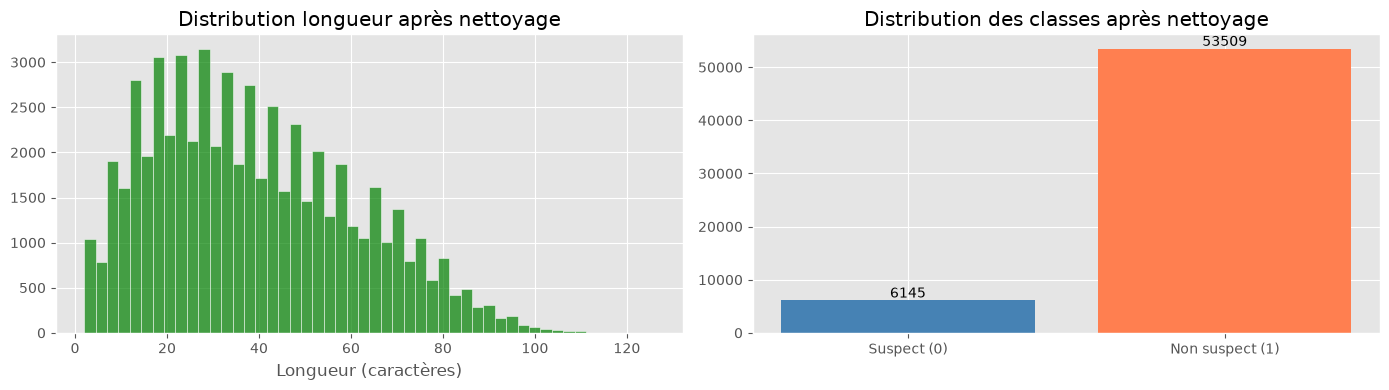

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))



axes[0].hist(df_clean['clean_message'].apply(len), bins=50,

             color='green', edgecolor='white', alpha=0.7)

axes[0].set_title('Distribution longueur après nettoyage')

axes[0].set_xlabel('Longueur (caractères)')



class_counts_clean = df_clean['label'].value_counts().sort_index()

axes[1].bar(['Suspect (0)', 'Non suspect (1)'], class_counts_clean.values,

           color=['steelblue', 'coral'])

axes[1].set_title('Distribution des classes après nettoyage')

for i, v in enumerate(class_counts_clean.values):

    axes[1].text(i, v + 500, str(v), ha='center')



plt.tight_layout()

plt.savefig('../reports/figures/post_cleaning_stats.png', dpi=150, bbox_inches='tight')

plt.show()

---

## 9. Visualisation des 20 mots les plus fréquents par classe

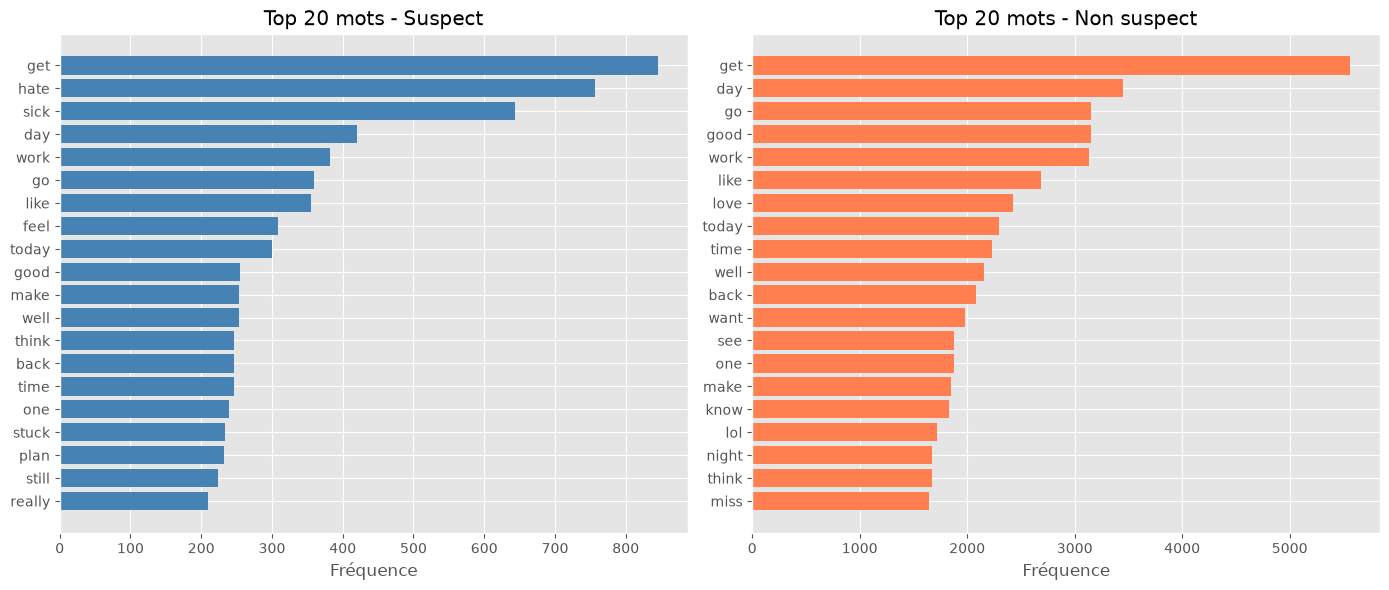

In [12]:
from collections import Counter



fig, axes = plt.subplots(1, 2, figsize=(14, 6))



for idx, label in enumerate([0, 1]):

    text = ' '.join(df_clean[df_clean['label'] == label]['clean_message'])

    word_counts = Counter(text.split()).most_common(20)

    words, counts = zip(*word_counts)

    axes[idx].barh(range(len(words)), counts, color=['steelblue', 'coral'][idx])

    axes[idx].set_yticks(range(len(words)))

    axes[idx].set_yticklabels(words)

    axes[idx].invert_yaxis()

    axes[idx].set_title(f"Top 20 mots - {'Suspect' if label==0 else 'Non suspect'}")

    axes[idx].set_xlabel('Fréquence')



plt.tight_layout()

plt.savefig('../reports/figures/top20_words_by_class.png', dpi=150, bbox_inches='tight')

plt.show()

---

## 10. Résumé et conclusions



| Constat | Action |

|---------|--------|

| Classes déséquilibrées (~ ratio X:1) | `class_weight='balanced'` ou SMOTE |

| Quelques valeurs manquantes | Remplissage par chaîne vide |

| Stop words, URLs, bruit | Nettoyage via `clean_text()` |

| Textes de longueur variable | TF-IDF gère les longueurs hétérogènes |



**Prochaine étape :** Représentation numérique (TF-IDF) et modélisation.